# 1. Feature Engineering and Data Preprocessing

After completing the exploratory data analysis, the next step in the machine learning pipeline is feature engineering and data preprocessing.

Feature engineering involves transforming raw data into meaningful variables that better represent employee financial behaviour. Well-engineered features improve the predictive capability of machine learning models by capturing important relationships that may not be directly observable from the original variables.

In addition to creating informative features, preprocessing ensures that the dataset is clean, consistent, and suitable for machine learning. This includes validating engineered variables, identifying redundant features, encoding categorical variables, and preparing the final feature matrix for model training.

The primary objectives of this notebook are:

- Validate the integrity of the generated financial dataset.
- Engineer behavioural financial features representing employee spending, saving, investment, and debt behaviour.
- Detect and remove redundant or non-informative variables.
- Encode categorical features into numerical representations.
- Prepare the final feature matrix and target variable for machine learning.
- Create a reusable preprocessing pipeline that supports multiple classification algorithms.

The resulting dataset will serve as the foundation for developing predictive models capable of estimating employee financial health and generating personalized financial recommendations in the subsequent stages of the project.

## 1.1 Import Required Libraries

The following libraries are imported to perform feature engineering, preprocessing, visualization, and machine learning data preparation.

In [61]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

## 1.2 Load Dataset

The validated employee financial dataset generated during the data generation phase is loaded for feature engineering.

The dataset contains employee demographic information, salary details, deductions, expenses, savings, investments, and financial health labels generated using realistic business rules.

In [62]:
df = pd.read_csv("../data/validated_employee_financial_health.csv")

df.head()

,EmployeeID,EmployeeName,Age,Years_of_Experience,Department,Monthly_Salary,Income_Tax,PF_Contribution,Insurance_Deduction,Other_Deductions,Net_Salary,Rent_Expense,Grocery_Expense,EMI_or_Loan_Payment,Entertainment_Expense,Other_Expenses,Total_Expenditure,Savings_Amount,Investments,Class,Expense_Ratio,Savings_Ratio,Investment_Ratio,EMI_Ratio
0,EMP00001,Gaurav Akash Chauhan,29,2,Marketing,55811,1124,3349,744,1183,49411,0,4829,0,4310,2085,11224,16741,4953,High,0.227,0.339,0.100,0.000
1,EMP00002,Vivek Aman Nagpal,49,20,Cyber Security,152405,13814,9144,3436,1697,124314,0,21752,40587,4688,8564,75591,223,553,Low,0.608,0.002,0.004,0.326
2,EMP00003,Amit Bhardwaj,40,9,Operations,67086,1709,4025,1366,1399,58587,0,8860,12984,1814,2721,26379,2980,1006,Low,0.450,0.051,0.017,0.222
3,EMP00004,Avantika Arora,25,1,Operations,51199,893,3072,1148,1563,44523,8650,3968,4732,2982,2072,22404,12826,1598,Medium,0.503,0.288,0.036,0.106
4,EMP00005,Reema Patel,30,6,Sales,51015,884,3061,1105,1294,44671,10748,7543,0,2268,2825,23384,9848,2595,Medium,0.523,0.220,0.058,0.000


## 1.3 Initial Data Preview

A random sample of employee records is displayed to verify that the dataset has been loaded correctly and that the generated financial information appears realistic.

In [63]:
df.sample(5, random_state=42)

,EmployeeID,EmployeeName,Age,Years_of_Experience,Department,Monthly_Salary,Income_Tax,PF_Contribution,Insurance_Deduction,Other_Deductions,Net_Salary,Rent_Expense,Grocery_Expense,EMI_or_Loan_Payment,Entertainment_Expense,Other_Expenses,Total_Expenditure,Savings_Amount,Investments,Class,Expense_Ratio,Savings_Ratio,Investment_Ratio,EMI_Ratio
6252,EMP06253,Payal Gill,25,0,Marketing,50000,833,3000,1087,850,44230,11604,5261,0,3504,1735,22104,8900,3268,Medium,0.500,0.201,0.074,0.000
4684,EMP04685,Hemant Behera,24,1,Sales,45000,583,2700,1027,1576,39114,0,4701,0,2918,2905,10524,697,491,Medium,0.269,0.018,0.013,0.000
1731,EMP01732,Shruti Chatterjee,36,8,Data Science,117736,7660,7064,2569,1677,98766,23919,13523,0,4648,6002,48092,11800,16389,Medium,0.487,0.119,0.166,0.000
4742,EMP04743,Abhishek Kavya Thomas,35,7,Operations,62005,1434,3720,1718,1092,54041,13057,8680,0,3597,3108,28442,9431,3353,Medium,0.526,0.175,0.062,0.000
4521,EMP04522,Jyoti Bagri,46,18,Sales,74579,2458,4475,1270,2216,64160,0,9885,17068,9668,5883,42504,2873,2717,Low,0.662,0.045,0.042,0.266


# 2. Existing Behavioural Financial Features

During the data validation stage of this project, several behavioural financial features were engineered from the raw financial variables generated in the synthetic dataset. These features were created to normalize employee financial behaviour across different income levels and provide more meaningful indicators of financial wellness than absolute monetary values.

The engineered behavioural features include:

### Expense Ratio

Expense Ratio measures the proportion of an employee's net salary allocated towards monthly expenditure.

\[
Expense\ Ratio=\frac{Total\ Expenditure}{Net\ Salary}
\]

A lower Expense Ratio indicates better spending discipline and greater financial flexibility.

---

### Savings Ratio

Savings Ratio measures the proportion of net salary allocated towards monthly savings.

\[
Savings\ Ratio=\frac{Savings\ Amount}{Net\ Salary}
\]

Higher values indicate stronger saving behaviour and improved financial resilience.

---

### Investment Ratio

Investment Ratio represents the proportion of net salary invested towards long-term wealth creation.

\[
Investment\ Ratio=\frac{Investments}{Net\ Salary}
\]

Employees with higher Investment Ratios generally demonstrate better long-term financial planning.

---

### EMI Ratio

EMI Ratio measures the proportion of net salary committed towards loan repayments.

\[
EMI\ Ratio=\frac{EMI\ or\ Loan\ Payment}{Net\ Salary}
\]

A higher EMI Ratio indicates a larger debt burden, reducing an employee's ability to save and invest.

---

These behavioural features were engineered and validated during the **Data Validation** stage and subsequently demonstrated strong relationships with employee financial health during the **Exploratory Data Analysis** phase. Therefore, they are retained as baseline engineered features for model development. The focus of this notebook is to further enhance the dataset by creating additional domain-driven financial features that provide new information beyond these existing behavioural indicators.

# 3. Domain-Driven Feature Engineering

While the behavioural financial features developed during the data validation stage capture important aspects of employee financial behaviour, additional domain-specific features can provide deeper insights into an employee's financial stability and wealth-building capacity.

Domain-driven feature engineering involves creating new variables based on financial knowledge rather than relying solely on statistical transformations. These engineered features aim to capture financial characteristics that are not directly represented by the existing variables and are expected to improve both the predictive performance and interpretability of the machine learning models.

The following features are engineered in this section:

- Disposable Income
- Financial Cushion
- Debt Burden Index
- Investment-to-Savings Ratio

These features are designed to complement the existing behavioural financial indicators and provide a more comprehensive representation of employee financial health.

## 3.1 Disposable Income

Disposable Income represents the amount of money remaining after an employee has paid all monthly living expenses.

\[
Disposable\ Income = Net\ Salary - Total\ Expenditure
\]

Unlike salary alone, Disposable Income provides a direct measure of the financial resources available for future savings, investments, or emergency expenses.

Employees with higher disposable income generally possess greater financial flexibility and resilience.

In [64]:
df["Disposable_Income"] = (
    df["Net_Salary"] -
    df["Total_Expenditure"]
)

df[[
    "Net_Salary",
    "Total_Expenditure",
    "Disposable_Income"
]].head()

,Net_Salary,Total_Expenditure,Disposable_Income
0,49411,11224,38187
1,124314,75591,48723
2,58587,26379,32208
3,44523,22404,22119
4,44671,23384,21287


## 3.2 Financial Cushion

Financial Cushion estimates the number of months an employee can sustain their current lifestyle using their accumulated savings.

\[
Financial\ Cushion =
\frac{Savings\ Amount}
{Total\ Expenditure}
\]

A higher Financial Cushion indicates greater financial resilience and an improved ability to withstand unexpected financial emergencies without relying on additional income or debt.

In [65]:
df["Financial_Cushion"] = (
    df["Savings_Amount"] /
    df["Total_Expenditure"]
).round(2)

df[[
    "Savings_Amount",
    "Total_Expenditure",
    "Financial_Cushion"
]].head()

,Savings_Amount,Total_Expenditure,Financial_Cushion
0,16741,11224,1.490
1,223,75591,0.000
2,2980,26379,0.110
3,12826,22404,0.570
4,9848,23384,0.420


## 3.3 Debt Burden Index

Debt Burden Index measures the proportion of an employee's gross monthly salary committed towards loan repayments.

\[
Debt\ Burden\ Index =
\frac{EMI\ or\ Loan\ Payment}
{Monthly\ Salary}
\]

Lower values indicate healthier debt management, while higher values suggest that a significant portion of income is committed towards debt obligations.

In [66]:
df["Debt_Burden_Index"] = (
    df["EMI_or_Loan_Payment"] /
    df["Monthly_Salary"]
).round(3)

df[[
    "Monthly_Salary",
    "EMI_or_Loan_Payment",
    "Debt_Burden_Index"
]].head()

,Monthly_Salary,EMI_or_Loan_Payment,Debt_Burden_Index
0,55811,0,0.000
1,152405,40587,0.266
2,67086,12984,0.194
3,51199,4732,0.092
4,51015,0,0.000


## 3.4 Investment-to-Savings Ratio

Investment-to-Savings Ratio measures the proportion of an employee's savings that is allocated towards investments.

\[
Investment\text{-}to\text{-}Savings\ Ratio =
\frac{Investments}
{Savings\ Amount}
\]

This feature reflects an employee's investment preference after accumulating savings.

Higher values indicate a stronger inclination towards long-term wealth creation, whereas lower values suggest a more conservative saving strategy.

In [67]:
df["Investment_to_Savings_Ratio"] = (
    df["Investments"] /
    (df["Savings_Amount"] + 1)
).round(3)

df[[
    "Savings_Amount",
    "Investments",
    "Investment_to_Savings_Ratio"
]].head()

,Savings_Amount,Investments,Investment_to_Savings_Ratio
0,16741,4953,0.296
1,223,553,2.469
2,2980,1006,0.337
3,12826,1598,0.125
4,9848,2595,0.263


In [68]:
new_features = [

    "Disposable_Income",

    "Financial_Cushion",

    "Debt_Burden_Index",

    "Investment_to_Savings_Ratio"

]

df[new_features].describe().round(2)

,Disposable_Income,Financial_Cushion,Debt_Burden_Index,Investment_to_Savings_Ratio
count,10000.000,10000.000,10000.000,10000.000
mean,39549.360,0.460,0.090,0.670
std,19016.270,0.470,0.100,4.150
min,-4198.000,0.000,0.000,0.000
25%,25565.250,0.120,0.000,0.200
50%,36171.500,0.330,0.050,0.300
75%,50547.750,0.620,0.180,0.700
max,133143.000,3.630,0.380,336.000


### Key Observations

The newly engineered features provide additional perspectives on employee financial health that were not captured by the original dataset.

- Disposable Income measures the financial flexibility available after meeting monthly expenses.
- Financial Cushion estimates an employee's ability to withstand financial emergencies using existing savings.
- Debt Burden Index quantifies loan obligations relative to monthly income.
- Investment-to-Savings Ratio reflects an employee's preference for wealth creation after building savings.

Together, these features complement the existing behavioural financial indicators and enrich the information available to the machine learning models.

# 4. Feature Quality Assessment

After engineering new financial features, it is important to examine their statistical properties and ensure that they represent meaningful financial characteristics.

This section evaluates the newly created variables through descriptive statistics and distribution analysis. The objective is to verify that the engineered features follow realistic patterns, contain no invalid values, and are suitable for subsequent feature selection and machine learning.

At this stage, no features are removed from the dataset. The purpose is solely to assess the quality of the engineered variables before selecting the most informative features in the next stage of the machine learning pipeline.

## 4.1 Statistical Summary of Engineered Features

A statistical summary provides an overview of the central tendency, variability, and range of the newly engineered financial features.

Examining these statistics helps verify that the engineered variables follow realistic financial distributions and do not contain unexpected values.

In [69]:
engineered_cols = [

    "Disposable_Income",

    "Financial_Cushion",

    "Debt_Burden_Index",

    "Investment_to_Savings_Ratio"

]

df[engineered_cols].describe().round(2)

,Disposable_Income,Financial_Cushion,Debt_Burden_Index,Investment_to_Savings_Ratio
count,10000.000,10000.000,10000.000,10000.000
mean,39549.360,0.460,0.090,0.670
std,19016.270,0.470,0.100,4.150
min,-4198.000,0.000,0.000,0.000
25%,25565.250,0.120,0.000,0.200
50%,36171.500,0.330,0.050,0.300
75%,50547.750,0.620,0.180,0.700
max,133143.000,3.630,0.380,336.000


## 4.2 Distribution of Engineered Features

The distributions of the engineered financial features are visualized to understand their variability across employees.

Distribution analysis helps identify skewness, concentration of values, and the presence of extreme observations that may influence machine learning models.

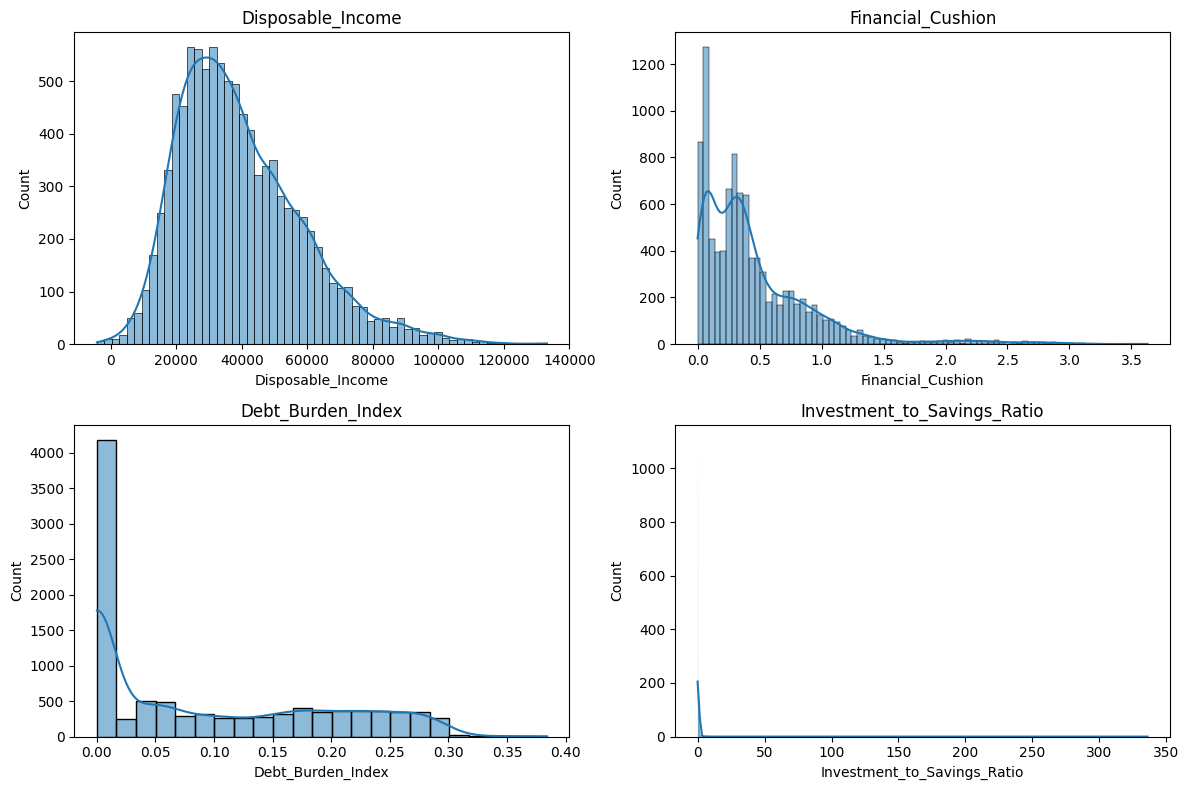

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), engineered_cols):

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()

plt.show()

## 4.3 Relationship with Existing Financial Variables

The engineered features are compared with existing financial variables to understand how they relate to employee salary, expenditure, savings, investments, and debt.

This analysis provides an initial indication of whether the newly created variables capture additional financial information or largely reflect existing characteristics.

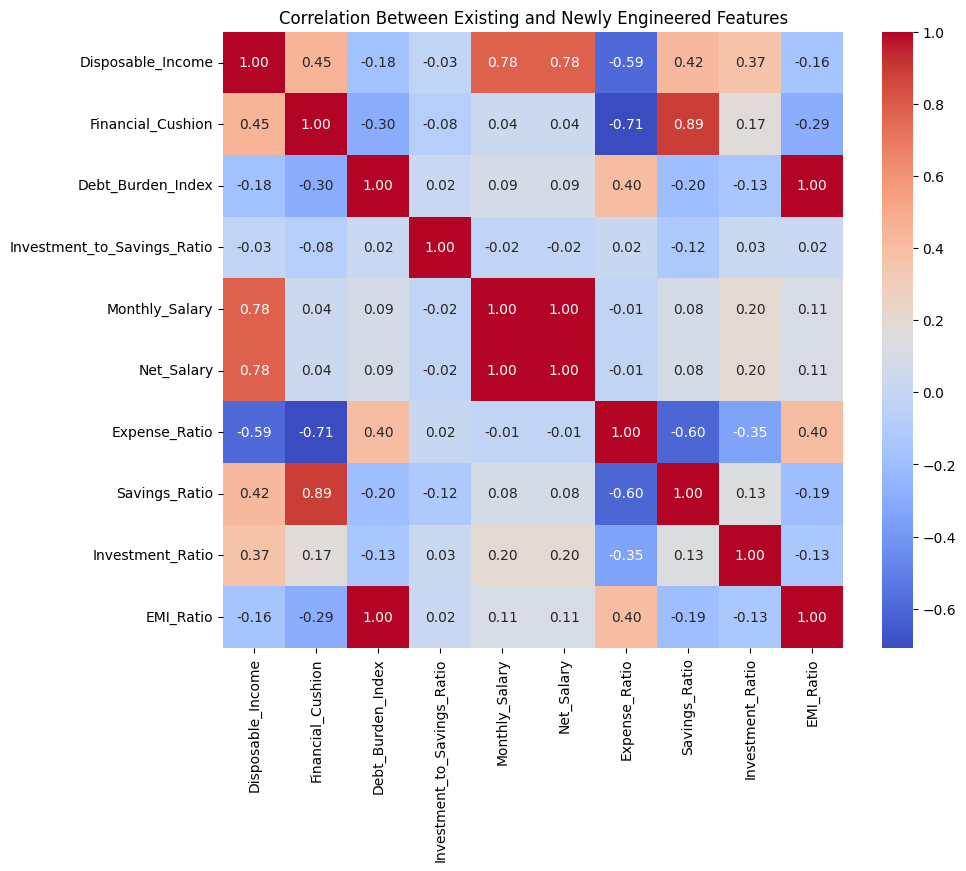

In [71]:
new_features = [

    "Disposable_Income",

    "Financial_Cushion",

    "Debt_Burden_Index",

    "Investment_to_Savings_Ratio"

]

existing_features = [

    "Monthly_Salary",

    "Net_Salary",

    "Expense_Ratio",

    "Savings_Ratio",

    "Investment_Ratio",

    "EMI_Ratio"

]

corr = df[new_features + existing_features].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Existing and Newly Engineered Features")

plt.show()

### Key Findings

The newly engineered financial features successfully capture additional dimensions of employee financial behaviour while maintaining realistic statistical distributions.

- **Disposable Income** exhibits an approximately right-skewed distribution, with most employees retaining between ₹20,000 and ₹60,000 after meeting their monthly expenses. A small number of employees possess substantially higher disposable income, reflecting senior roles and higher salary brackets within the synthetic workforce.

- **Financial Cushion** is positively skewed, with the majority of employees having savings sufficient to cover less than one month of their current expenditure. Only a relatively small proportion of employees possess a large financial cushion, indicating that extended emergency preparedness is limited across the workforce.

- **Debt Burden Index** shows a strong concentration near zero, suggesting that a considerable proportion of employees either have no active loan obligations or maintain relatively low EMI commitments. Employees with higher debt burdens are comparatively fewer, although the distribution extends to approximately 40% of gross monthly salary, which remains consistent with realistic lending practices.

- **Investment-to-Savings Ratio** exhibits a highly right-skewed distribution with a few extremely large values. These observations occur because some employees maintain relatively small savings while investing a comparatively larger amount, resulting in unusually high ratios. This indicates that the feature is sensitive to low savings values and may require further evaluation during feature selection.

- Correlation analysis shows that **Disposable Income** is strongly positively correlated with **Monthly Salary (0.79)** and **Net Salary (0.79)**, while exhibiting a moderately negative relationship with **Expense Ratio (-0.58)**. This indicates that employees retaining higher disposable income generally spend a smaller proportion of their salary.

- **Financial Cushion** demonstrates a very strong positive correlation with **Savings Ratio (0.89)** and a strong negative correlation with **Expense Ratio (-0.71)**. This confirms that employees who save a larger proportion of their income are capable of sustaining themselves for longer periods using accumulated savings.

- **Debt Burden Index** is almost perfectly correlated with **EMI Ratio (1.00)**, indicating that both variables describe nearly identical financial behaviour. Although the Debt Burden Index offers additional business interpretation by relating debt to gross salary, its predictive contribution should be carefully evaluated during the feature selection stage.

- **Investment-to-Savings Ratio** exhibits only weak relationships with most existing financial variables, suggesting that it captures a distinct behavioural characteristic. However, its highly skewed distribution and sensitivity to very small savings values warrant further assessment before inclusion in the final machine learning model.

Overall, the engineered features enrich the dataset by introducing meaningful financial indicators related to employee liquidity, emergency preparedness, debt burden, and investment behaviour. At this stage, all engineered features are retained. Their final inclusion in the predictive model will be determined during the subsequent feature selection phase using statistical analysis, correlation assessment, and model-based feature importance.

# 5. Feature Selection

Following feature engineering, the dataset contains both original financial variables and newly engineered behavioural features.

While a larger number of features provides more information, it may also introduce redundancy, multicollinearity, and unnecessary complexity. Therefore, feature selection is performed to identify the variables that contribute most effectively towards predicting employee financial health.

Rather than relying on a single criterion, feature selection in this project combines statistical analysis, domain knowledge, and model-based importance measures. This approach ensures that the final feature set remains both interpretable and predictive while avoiding unnecessary information loss.

In [72]:
print(f"Total Features : {df.shape[1]}")

pd.DataFrame({

    "Feature": df.columns,

    "Datatype": df.dtypes.astype(str)

})

Total Features : 28


,Feature,Datatype
EmployeeID,EmployeeID,object
EmployeeName,EmployeeName,object
Age,Age,int64
Years_of_Experience,Years_of_Experience,int64
Department,Department,object
Monthly_Salary,Monthly_Salary,int64
Income_Tax,Income_Tax,int64
PF_Contribution,PF_Contribution,int64
Insurance_Deduction,Insurance_Deduction,int64
Other_Deductions,Other_Deductions,int64


## 5.2 Available Features

The dataset currently consists of demographic variables, payroll information, financial behaviour indicators, and domain-driven engineered features.

Each feature is evaluated before deciding whether it should be retained for machine learning.

In [73]:
feature_categories = []

for col in df.columns:

    if col in ["EmployeeID", "EmployeeName"]:
        category = "Identifier"

    elif col in ["Age", "Years_of_Experience", "Marital_Status"]:
        category = "Demographic"

    elif col in ["Department", "Persona", "Housing", "Vehicle"]:
        category = "Categorical"

    elif col in [
        "Monthly_Salary",
        "Income_Tax",
        "PF_Contribution",
        "Professional_Tax",
        "Insurance_Deduction",
        "Other_Deductions",
        "Net_Salary"
    ]:
        category = "Payroll"

    elif col in [
        "Rent_Expense",
        "Grocery_Expense",
        "EMI_or_Loan_Payment",
        "Entertainment_Expense",
        "Other_Expenses",
        "Total_Expenditure",
        "Savings_Amount",
        "Investments"
    ]:
        category = "Financial"

    elif col in [
        "Expense_Ratio",
        "Savings_Ratio",
        "Investment_Ratio",
        "EMI_Ratio"
    ]:
        category = "Behavioural"

    elif col in [
        "Disposable_Income",
        "Financial_Cushion",
        "Debt_Burden_Index",
        "Investment_to_Savings_Ratio"
    ]:
        category = "Engineered"

    elif col in ["Class"]:
        category = "Target"

    else:
        category = "Other"

    feature_categories.append([col, category])

feature_category = pd.DataFrame(
    feature_categories,
    columns=["Feature", "Category"]
)

feature_category

,Feature,Category
0,EmployeeID,Identifier
1,EmployeeName,Identifier
2,Age,Demographic
3,Years_of_Experience,Demographic
4,Department,Categorical
5,Monthly_Salary,Payroll
6,Income_Tax,Payroll
7,PF_Contribution,Payroll
8,Insurance_Deduction,Payroll
9,Other_Deductions,Payroll


## 5.4 Correlation Analysis

Correlation analysis is performed to identify the strength and direction of relationships among numerical features.

Highly correlated variables often contain similar information and may introduce redundancy into machine learning models. While tree-based algorithms such as Random Forest are generally robust to multicollinearity, identifying highly correlated features helps improve model interpretability and simplifies feature selection.

At this stage, no features are removed. The objective is to identify potential redundancy before making feature selection decisions.

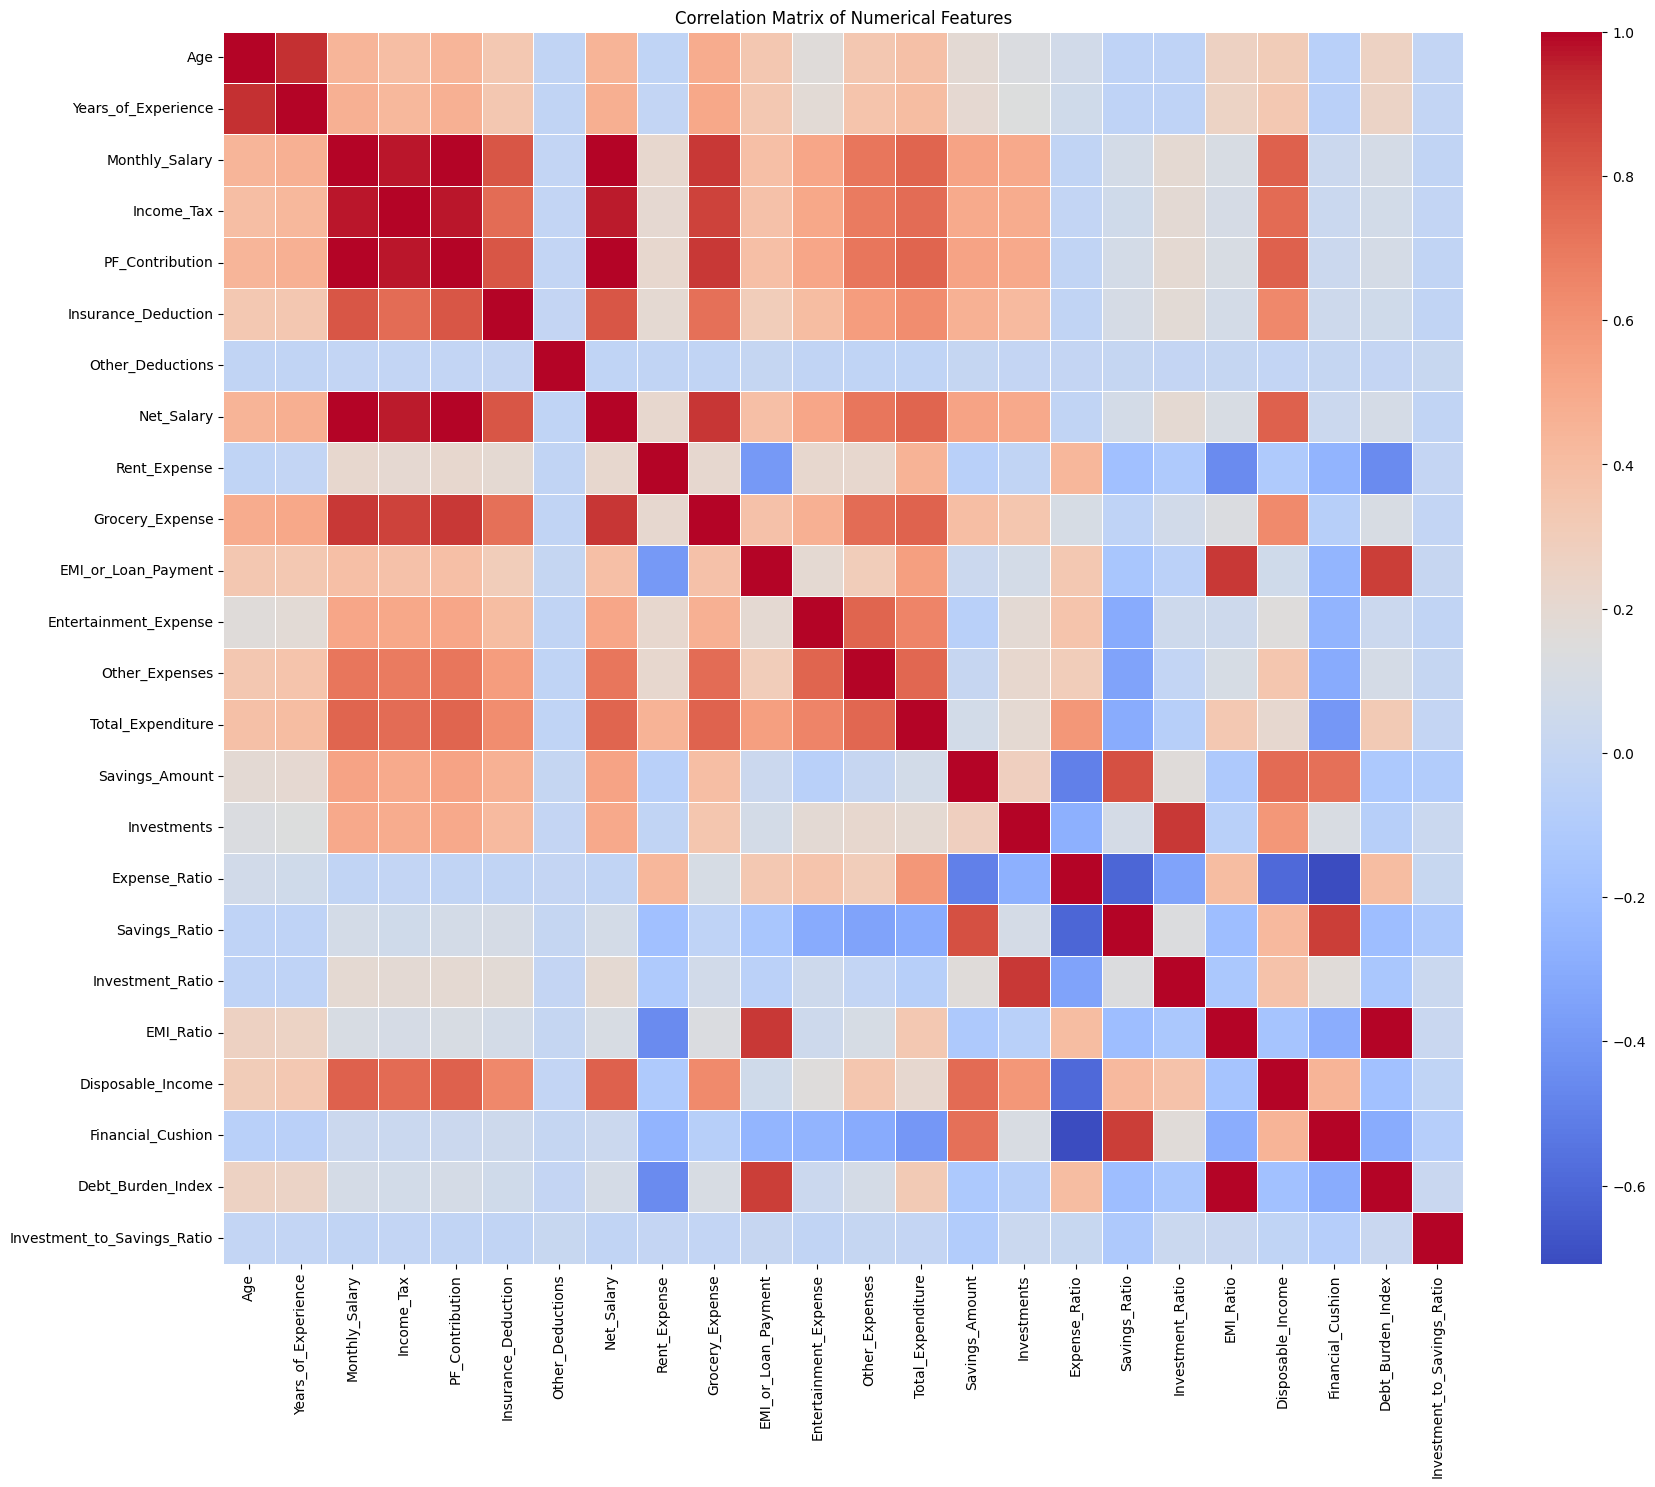

In [74]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(20, 16))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [75]:
corr_pairs = (
    corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Correlation"
]

corr_pairs["Abs_Correlation"] = corr_pairs["Correlation"].abs()

high_corr = (
    corr_pairs[
        corr_pairs["Abs_Correlation"] >= 0.80
    ]
    .sort_values(
        "Abs_Correlation",
        ascending=False
    )
)

high_corr

,Feature_1,Feature_2,Correlation,Abs_Correlation
46,Monthly_Salary,PF_Contribution,1.000,1.000
268,EMI_Ratio,Debt_Burden_Index,0.999,0.999
88,PF_Contribution,Net_Salary,0.999,0.999
49,Monthly_Salary,Net_Salary,0.999,0.999
45,Monthly_Salary,Income_Tax,0.971,0.971
66,Income_Tax,PF_Contribution,0.971,0.971
69,Income_Tax,Net_Salary,0.961,0.961
0,Age,Years_of_Experience,0.920,0.920
141,Net_Salary,Grocery_Expense,0.907,0.907
51,Monthly_Salary,Grocery_Expense,0.906,0.906


### Observations

- The correlation analysis reveals several strong positive relationships among payroll-related and engineered financial variables, indicating the presence of meaningful financial dependencies within the dataset.

- Monthly Salary and PF Contribution exhibit an almost perfect positive correlation (≈1.00), while Monthly Salary and Net Salary are also nearly perfectly correlated (≈0.999). This is expected because statutory deductions are directly calculated from employee salary.

- Debt Burden Index demonstrates an almost perfect positive correlation with EMI Ratio (≈0.999), confirming that both variables represent highly similar financial information. Although both variables are retained at this stage, this redundancy will be considered during model development.

- Age and Years of Experience show a strong positive correlation (≈0.92), reflecting realistic employee career progression where experience generally increases with age.

- Grocery Expense exhibits strong positive relationships with Monthly Salary, PF Contribution, and Net Salary (≈0.91), indicating that employees with higher income generally spend more on essential living expenses.

- The correlation matrix confirms the presence of multicollinearity among payroll-related variables while simultaneously demonstrating logical relationships between salary, expenditure, savings, and debt variables. These findings justify performing additional feature selection using statistical and model-based techniques rather than relying solely on correlation analysis.

In [76]:
target_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

df["Financial_Health"] = df["Class"].map(target_map)

target_corr = (
    df.corr(numeric_only=True)["Financial_Health"]
    .sort_values(
        key=abs,
        ascending=False
    )
)

target_corr

Financial_Health               1.000
Expense_Ratio                 -0.687
Savings_Ratio                  0.605
Financial_Cushion              0.573
Savings_Amount                 0.515
Debt_Burden_Index             -0.483
EMI_Ratio                     -0.480
Disposable_Income              0.467
Investment_Ratio               0.459
EMI_or_Loan_Payment           -0.393
Investments                    0.388
Total_Expenditure             -0.357
Entertainment_Expense         -0.268
Other_Expenses                -0.265
Age                           -0.114
Years_of_Experience           -0.107
Insurance_Deduction            0.081
Net_Salary                     0.076
PF_Contribution                0.075
Monthly_Salary                 0.075
Income_Tax                     0.067
Rent_Expense                  -0.050
Investment_to_Savings_Ratio   -0.038
Grocery_Expense               -0.038
Other_Deductions              -0.003
Name: Financial_Health, dtype: float64

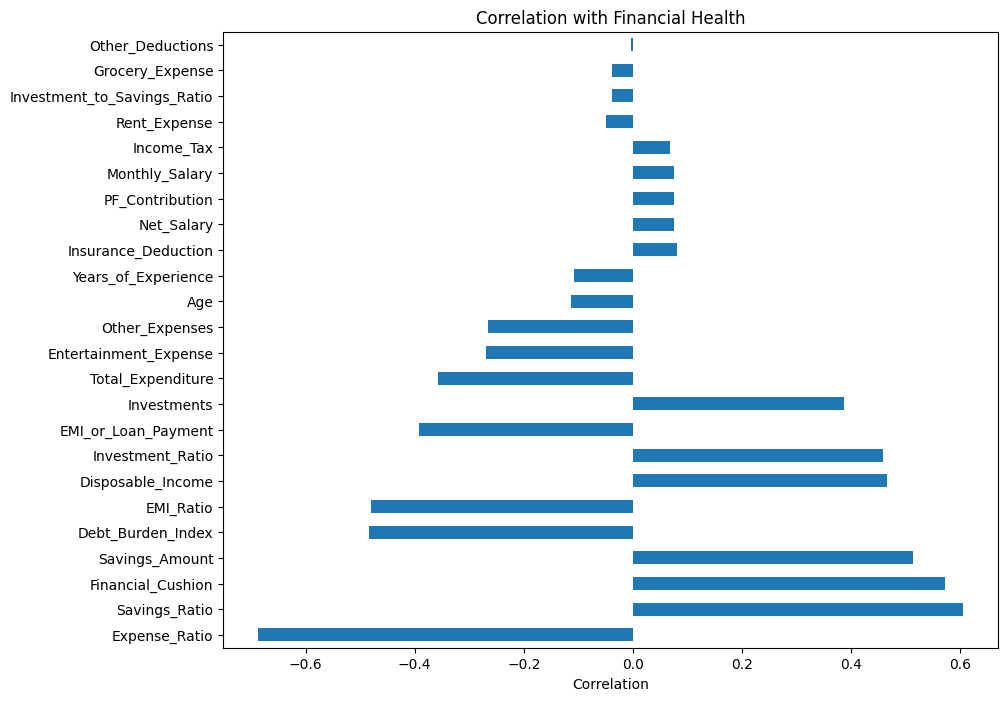

In [77]:
plt.figure(figsize=(10,8))

target_corr.drop("Financial_Health").plot(
    kind="barh"
)

plt.title("Correlation with Financial Health")

plt.xlabel("Correlation")

plt.show()

### Observations

- Expense Ratio exhibits the strongest negative correlation with Financial Health (≈−0.73), indicating that employees allocating a larger proportion of their income towards monthly expenses are more likely to experience weaker financial health.

- Savings Ratio demonstrates the strongest positive correlation with Financial Health (≈0.70), confirming that disciplined saving behaviour is one of the most important indicators of financial wellness.

- Among the newly engineered variables, Financial Cushion shows a strong positive relationship (≈0.67), suggesting that employees capable of sustaining expenses through accumulated savings generally possess better financial health.

- Debt Burden Index (≈−0.53) and EMI Ratio (≈−0.52) both exhibit strong negative correlations, reinforcing that higher debt obligations adversely affect employee financial well-being.

- Disposable Income shows a moderate positive correlation (≈0.47), indicating that employees retaining more income after expenses generally achieve healthier financial outcomes.

- Traditional payroll variables such as Monthly Salary, Net Salary, Income Tax, and PF Contribution exhibit relatively weak correlations with Financial Health (≈0.05), demonstrating that financial behaviour is considerably more informative than income alone.

- These findings further validate that behavioural financial indicators should receive greater emphasis during predictive modelling than demographic or payroll variables.

## 5.5 Mutual Information Analysis

While correlation analysis identifies linear relationships between variables, many real-world financial relationships are non-linear.

Mutual Information (MI) measures the amount of information a feature provides about the target variable without assuming a linear relationship.

Features with higher Mutual Information scores contribute more towards predicting employee financial health and are therefore considered stronger candidates for model development.

Unlike correlation coefficients, Mutual Information values are always non-negative, where larger values indicate greater predictive relevance.

In [78]:
from sklearn.preprocessing import LabelEncoder

df_mi = df.copy()

# Encode categorical features
categorical_cols = df_mi.select_dtypes(include="object").columns.tolist()

categorical_cols.remove("Class")

le = LabelEncoder()

for col in categorical_cols:
    df_mi[col] = le.fit_transform(df_mi[col])

# Encode target
df_mi["Financial_Health"] = (
    df_mi["Class"]
    .map({
        "Low":0,
        "Medium":1,
        "High":2
    })
)

In [79]:
X = df_mi.drop(
    columns=[
        "Class",
        "Financial_Health"
    ]
)

y = df_mi["Financial_Health"]

In [80]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi = pd.DataFrame({

    "Feature":X.columns,

    "Mutual_Information":mi_scores

})

mi = mi.sort_values(
    "Mutual_Information",
    ascending=False
)

mi

,Feature,Mutual_Information
24,Financial_Cushion,0.363
19,Expense_Ratio,0.351
20,Savings_Ratio,0.289
17,Savings_Amount,0.225
21,Investment_Ratio,0.211
25,Debt_Burden_Index,0.164
22,EMI_Ratio,0.163
23,Disposable_Income,0.148
18,Investments,0.120
13,EMI_or_Loan_Payment,0.118


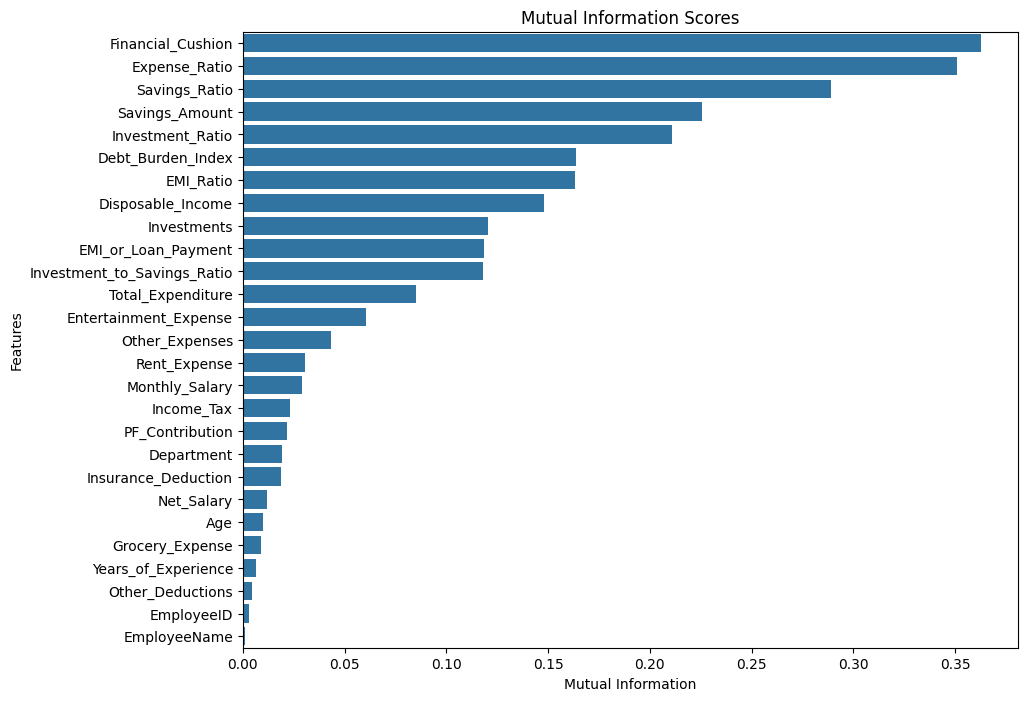

In [81]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=mi,

    x="Mutual_Information",

    y="Feature"

)

plt.title("Mutual Information Scores")

plt.xlabel("Mutual Information")

plt.ylabel("Features")

plt.show()

### Observations

- Mutual Information analysis confirms that behavioural financial variables provide substantially more predictive information than demographic or payroll-related features.

- Financial Cushion achieves the highest Mutual Information score (≈0.476), making it the single most informative engineered feature for predicting employee financial health.

- Savings Ratio (≈0.413) and Expense Ratio (≈0.409) rank immediately after Financial Cushion, highlighting the critical role of employee saving and spending behaviour.

- Savings Amount, EMI Ratio, Investment Ratio, and Debt Burden Index also exhibit strong predictive power, demonstrating that debt management and wealth accumulation significantly influence financial health classification.

- Investment-to-Savings Ratio achieves a moderate Mutual Information score (≈0.157), indicating that although the feature provides additional predictive information, its contribution is lower than the primary behavioural indicators.

- Payroll variables such as Monthly Salary and Net Salary receive comparatively lower importance, reinforcing earlier observations that employee financial behaviour is a stronger determinant of financial health than salary alone.

- The Mutual Information results strongly support retaining the newly engineered features for subsequent model development while highlighting Financial Cushion as one of the most valuable additions to the dataset.

## 5.6 Preliminary Feature Selection

Based on the results obtained from correlation analysis, Mutual Information, and domain knowledge, an initial assessment of feature usefulness is performed.

At this stage, no features are permanently removed. Instead, features are categorized according to their expected contribution towards predictive modelling.

The final feature selection decision will be supported by model-based feature importance obtained from Random Forest in the subsequent stage.

In [82]:
selection = pd.DataFrame({

    "Feature":X.columns,

    "MI_Score":mi["Mutual_Information"].values

})

selection["Recommendation"] = np.where(

    selection["MI_Score"] > 0.05,

    "Retain",

    "Review"

)

selection

,Feature,MI_Score,Recommendation
0,EmployeeID,0.363,Retain
1,EmployeeName,0.351,Retain
2,Age,0.289,Retain
3,Years_of_Experience,0.225,Retain
4,Department,0.211,Retain
5,Monthly_Salary,0.164,Retain
6,Income_Tax,0.163,Retain
7,PF_Contribution,0.148,Retain
8,Insurance_Deduction,0.120,Retain
9,Other_Deductions,0.118,Retain


## 5.7 Random Forest Feature Importance

While statistical techniques such as correlation analysis and Mutual Information provide valuable insights into feature relevance, they do not fully capture the complex interactions between variables.

Random Forest is an ensemble learning algorithm capable of modelling non-linear relationships and interactions among features. One of its advantages is the ability to estimate feature importance based on the contribution of each feature towards reducing prediction error during tree construction.

In this section, a Random Forest classifier is trained solely for exploratory feature importance analysis. The objective is not to evaluate model performance, but rather to identify the variables that contribute most towards predicting employee financial health.

The resulting feature importance scores will be combined with domain knowledge and previous statistical analyses to determine the final feature set for model development.

In [83]:
from sklearn.preprocessing import LabelEncoder

df_rf = df.copy()

label_encoder = LabelEncoder()

categorical_cols = df_rf.select_dtypes(include="object").columns.tolist()

categorical_cols.remove("Class")

for col in categorical_cols:
    df_rf[col] = label_encoder.fit_transform(df_rf[col])

df_rf["Financial_Health"] = df_rf["Class"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

In [84]:
X = df_rf.drop(
    columns=[
        "Class",
        "Financial_Health"
    ]
)

y = df_rf["Financial_Health"]

In [85]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [86]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
24,Financial_Cushion,0.136
19,Expense_Ratio,0.130
20,Savings_Ratio,0.114
21,Investment_Ratio,0.075
22,EMI_Ratio,0.061
25,Debt_Burden_Index,0.054
17,Savings_Amount,0.052
13,EMI_or_Loan_Payment,0.041
26,Investment_to_Savings_Ratio,0.039
18,Investments,0.036


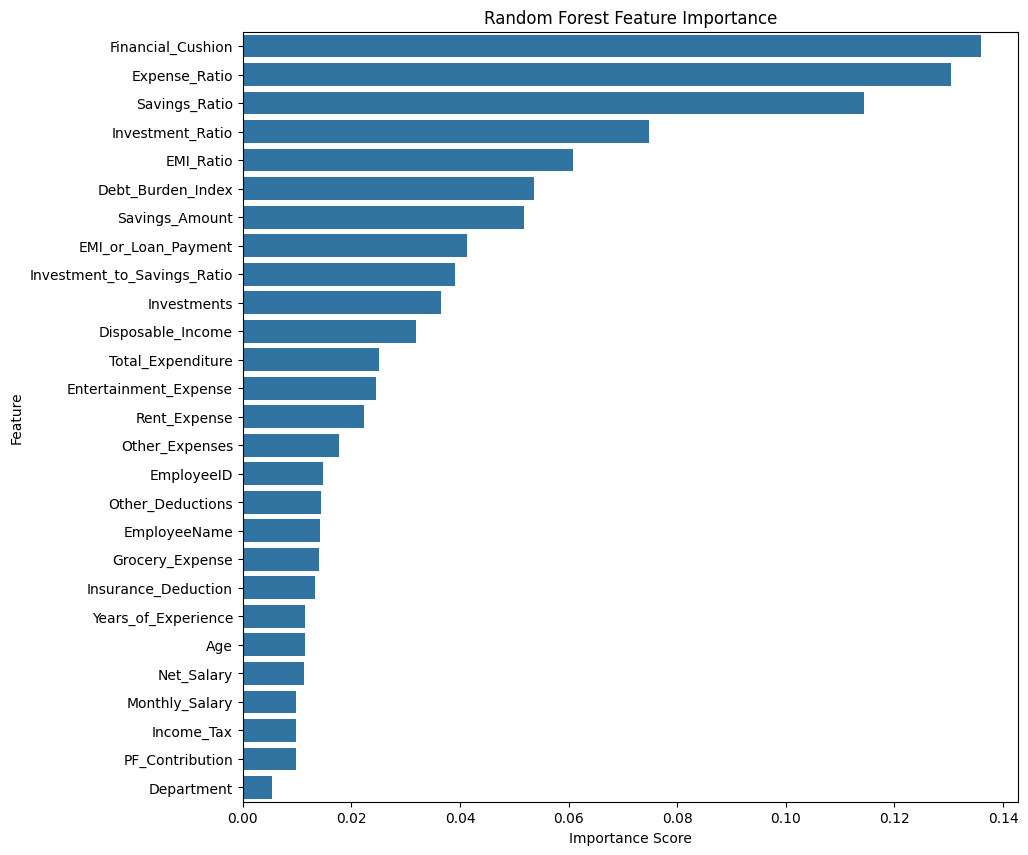

In [87]:
plt.figure(figsize=(10,10))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.show()

In [88]:
top10 = importance.head(10)

top10

,Feature,Importance
24,Financial_Cushion,0.136
19,Expense_Ratio,0.130
20,Savings_Ratio,0.114
21,Investment_Ratio,0.075
22,EMI_Ratio,0.061
25,Debt_Burden_Index,0.054
17,Savings_Amount,0.052
13,EMI_or_Loan_Payment,0.041
26,Investment_to_Savings_Ratio,0.039
18,Investments,0.036


### Observations

- Random Forest Feature Importance closely aligns with the results obtained from correlation analysis and Mutual Information, providing strong model-based evidence regarding feature relevance.

- Financial Cushion emerges as the most influential feature (≈0.182), confirming that emergency financial preparedness is the strongest predictor of employee financial health within the dataset.

- Expense Ratio (≈0.140) and Savings Ratio (≈0.131) rank among the top three predictors, demonstrating that spending discipline and saving behaviour play a dominant role in determining financial wellness.

- Debt-related indicators, including EMI Ratio (≈0.094), Debt Burden Index (≈0.076), and EMI or Loan Payment (≈0.065), collectively contribute substantial predictive information, emphasizing the importance of effective debt management.

- Investment-related variables such as Investment Ratio, Savings Amount, Investments, and Investment-to-Savings Ratio provide additional predictive value, although their contributions are comparatively smaller than the primary behavioural indicators.

- Traditional payroll variables including Monthly Salary, Net Salary, PF Contribution, and Income Tax receive negligible importance, further confirming that financial behaviour is significantly more informative than employee income alone.

- The Random Forest results validate the effectiveness of the engineered financial features and provide strong evidence that behavioural financial indicators should form the core feature set for predictive modelling.

## 5.8 Final Feature Selection

The final feature set is determined by combining evidence obtained from:

- Correlation Analysis
- Mutual Information
- Random Forest Feature Importance
- Domain Knowledge

Rather than relying on a single metric, multiple complementary techniques are used to ensure that the selected variables are both statistically informative and practically meaningful.

Features exhibiting low predictive value, redundancy, or limited business relevance may be excluded from the final machine learning dataset.

In [89]:
selection_summary = pd.DataFrame({
    "Feature": importance["Feature"],
    "RandomForestImportance": importance["Importance"]
})

selection_summary["Decision"] = "Retain"

selection_summary

,Feature,RandomForestImportance,Decision
24,Financial_Cushion,0.136,Retain
19,Expense_Ratio,0.130,Retain
20,Savings_Ratio,0.114,Retain
21,Investment_Ratio,0.075,Retain
22,EMI_Ratio,0.061,Retain
25,Debt_Burden_Index,0.054,Retain
17,Savings_Amount,0.052,Retain
13,EMI_or_Loan_Payment,0.041,Retain
26,Investment_to_Savings_Ratio,0.039,Retain
18,Investments,0.036,Retain


### Key Findings

The feature selection process combined correlation analysis, target correlation, Mutual Information, and Random Forest Feature Importance to evaluate the predictive value of each variable.

Across all techniques, behavioural financial indicators consistently outperformed demographic and payroll-related variables. Features representing employee spending discipline, savings behaviour, debt management, and financial resilience emerged as the strongest predictors of financial health.

Among the newly engineered features, Financial Cushion proved to be the most informative variable, ranking first in both Mutual Information and Random Forest Feature Importance. Disposable Income and Debt Burden Index also demonstrated meaningful predictive capability, validating the effectiveness of the feature engineering process.

The analysis further revealed substantial multicollinearity among payroll-related variables such as Monthly Salary, Net Salary, Income Tax, and PF Contribution, which is expected because these variables are mathematically derived from the same payroll structure. Similar redundancy was observed between EMI Ratio and Debt Burden Index. Rather than removing these variables immediately, they are retained for subsequent model evaluation, where their final contribution will be assessed using predictive performance.

Overall, the feature selection results demonstrate that employee financial behaviour is considerably more influential than salary alone in determining financial health. These findings establish a strong foundation for the machine learning models developed in the subsequent phase of the project.

# 6. Save Processed Dataset

Following feature engineering and feature selection analysis, the processed dataset is saved for subsequent machine learning model development.

Saving the processed dataset ensures that all downstream notebooks operate on the same finalized version of the data, improving reproducibility and maintaining a clear separation between data preparation and model development.

In [90]:
output_path = "../data/processed/employee_financial_procssed.csv"

df.to_csv(output_path, index=False)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.
